# Project Part 4: Model Improvement and Progress Report

- **Team number:** `#`
- **Team members:** `Tuan Lo`, `Cole Beach`
- **Project title:** Music Genre Classification
- **Dataset name:** Music Genre Classification Dataset (Kaggle `train.csv` / `test.csv`)
- **Target variable:** `Class` (11 genre labels, 0-10)
- **Prediction task:** Supervised multiclass classification - predict genre from audio descriptors and popularity metadata


**Table of contents**

- [1. Project Status Summary](#section1)
- [2. Data and Feature Updates](#section2)
- [3. Model Improvement and Comparison](#section3)
- [4. Ensemble Connection](#section4)
- [5. Current Evaluation Results](#section5)
- [6. Visual Evidence](#section6)
- [7. Current Challenges](#section7)
- [8. Plan for Completion](#section8)
- [Graduate Extension: Deeper Progress Analysis](#graduate)


## <a id='section1'></a>1. Project Status Summary

We continue the Kaggle Music Genre Classification problem from Parts 1–3: predict one of eleven genre labels from Spotify-style audio summaries and popularity. The labeled training set contains 17,996 songs after deduplication. We keep the Part 3 stratified 60% / 20% / 20% train / validation / test split from `train.csv`; headline metrics below are on the held-out **test** fold (~20%), not the unlabeled Kaggle submission file.

Since Part 3, the pipeline changed in four ways. We expanded the feature block from nine to eleven predictors by re-including `key`, `valence`, `liveness`, and `mode` while dropping `tempo` and `time_signature`. We bundle median imputation (and `MinMaxScaler` for Part 4 models) inside sklearn `Pipeline` objects so every preprocessing step is fit on training data only. We compared bagging (random forest) against boosting (AdaBoost) on the revised feature set. We also tested IQR-based outlier removal and rejected it because held-out accuracy fell.

Part 3's best supervised model - random forest on nine unscaled features - reached 50.3% accuracy and 47.7% weighted F1 on this same stratified test fold. Part 4 investigates whether feature revision and ensemble methods improve on that Part 3 baseline, while keeping minority-class recall visible through macro F1.


## <a id='section2'></a>2. Data and Feature Updates

### Preprocessing pipeline

The Part 4 notebook reuses Part 3's split discipline:

1. Load `../data/raw/train.csv` and drop exact duplicate rows.
2. Stratified 60% / 20% / 20% train / validation / test split (`RANDOM_STATE=42`).
3. Model-specific feature subsets selected on raw splits (missing values retained until fit time).
4. Each estimator uses a sklearn `Pipeline` with train-fit `SimpleImputer(strategy="median")`; Part 4 models add `MinMaxScaler` before the classifier (no validation or test statistics in preprocessing).

The validation split is reserved for final hyperparameter tuning (as in Part 3 Section 9). The Part 4 comparison trains on the training fold only and reports held-out **test** results for fixed configurations (Part 3 RF settings and our Part 4 RF/AdaBoost settings)-we did not select those configs using validation scores in this notebook.

Kaggle `test.csv` remains reserved for final submission; all metrics below come from the labeled test fold.

### Changes since Part 3

| Aspect | Part 3 | Part 4 | Rationale |
|--------|--------|--------|-----------|
| Features | 9 (`tempo`, `time_signature` included) | 11 (`key`, `valence`, `liveness`, `mode` added; rhythm columns dropped) | Part 2 EDA ranked duration, acousticness, and energy highest; our feature ablation adds harmonic/mood descriptors |
| Preprocessing | Median impute fit on train, applied to val/test | `SimpleImputer` + `MinMaxScaler` in each Part 4 pipeline | Imputation and scaling both refit inside the pipeline on the training fold only |
| Outliers | Kept (Part 2 policy) | IQR filter tested, rejected | Removing high-IQR rows lowered accuracy in preliminary runs |
| Class weights | None | None yet | Planned for final submission |
| Split | Stratified 60/20/20 | Same fractions and seed | Keeps Part 3 vs Part 4 comparisons valid |

### Missing values

Median imputation targets the same columns as earlier parts: `Popularity` (428 missing), `instrumentalness` (4,377), and `key` (2,014 on the full CSV before split). All other modeling columns are complete on the feature subsets we use.

### Feature lists

**Part 3 (`MODEL_FEATURES_V3`):** Popularity, energy, loudness, acousticness, instrumentalness, duration_in min/ms, speechiness, tempo, time_signature.

**Part 4 (`MODEL_FEATURES_V4`):** Popularity, energy, loudness, acousticness, instrumentalness, duration_in min/ms, speechiness, key, valence, liveness, mode.

Prose and code now agree: the expanded set deliberately keeps mood and harmonic descriptors that Part 3 dropped, while removing rhythm encodings we treat as redundant with duration and energy splits.


In [11]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

RANDOM_STATE = 42
HOLDOUT_TEST_FRACTION = 0.2
VAL_FRACTION_OF_TEMP = 0.25

DATA_DIR = Path("../data/raw")
TRAIN_PATH = DATA_DIR / "train.csv"
TARGET_COL = "Class"

MODEL_FEATURES_V3 = ['Popularity', 'energy', 'loudness', 'acousticness', 'instrumentalness', 'duration_in min/ms', 'speechiness', 'tempo', 'time_signature']

MODEL_FEATURES_V4 = ['Popularity', 'energy', 'loudness', 'acousticness', 'instrumentalness', 'duration_in min/ms', 'speechiness', 'key', 'valence', 'liveness', 'mode']

data = pd.read_csv(TRAIN_PATH)
rows_before = len(data)
data = data.drop_duplicates(keep="first").copy()
print(f"Rows after deduplication: {len(data):,} (removed {rows_before - len(data)} duplicates)")

all_features = sorted(set(MODEL_FEATURES_V3) | set(MODEL_FEATURES_V4))
print("\nMissing values on modeling columns:")
print(data[all_features].isna().sum().sort_values(ascending=False))


Rows after deduplication: 17,996 (removed 0 duplicates)

Missing values on modeling columns:
instrumentalness      4377
key                   2014
Popularity             428
duration_in min/ms       0
acousticness             0
energy                   0
liveness                 0
loudness                 0
mode                     0
speechiness              0
tempo                    0
time_signature           0
valence                  0
dtype: int64


## <a id='section3'></a>3. Model Improvement and Comparison

We compare four setups, each with a defined role:

1. **Majority-class dummy (Part 3 baseline floor).** Always predicts the modal training genre. At ~27.5% accuracy on an 11-class task, it sets the minimum bar any learned model must clear.
2. **Part 3 random forest reproduced.** Same nine features, no scaling, 200 trees, entropy, `max_depth=12`. This is the direct Part 3 benchmark on the shared test fold.
3. **Improved random forest.** Eleven features with median impute + `MinMaxScaler` in one pipeline, 200 trees, entropy, `max_depth=10` (our Part 4 configuration, with preprocessing fit on training data only). Tests whether the revised feature set and RF configuration improve beyond Part 3; scaling is kept inside the pipeline for preprocessing consistency, even though tree models are not scale-sensitive in the same way as distance-based or linear models.
4. **AdaBoost.** Same eleven-feature pipeline with 200 boosted decision trees using `max_depth=9` (our Part 4 AdaBoost configuration). Provides a boosting contrast to RF's bagging for the ensemble discussion.

Decision trees alone are omitted from the headline table because Part 3 already showed a single tree at ~46% accuracy; the ensemble comparisons are the substantive Part 4 step.

Each model is fit on the training portion of the split and scored once on the test fold; the validation portion is held aside and not used for the numbers in the table below.


In [12]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier


def model_pipeline(*, scale: bool, clf) -> Pipeline:
    steps = [("imputer", SimpleImputer(strategy="median"))]
    if scale:
        steps.append(("scaler", MinMaxScaler()))
    steps.append(("clf", clf))
    return Pipeline(steps)


all_features = sorted(set(MODEL_FEATURES_V3) | set(MODEL_FEATURES_V4))
X_full = data[all_features].copy()
y = data[TARGET_COL].copy()

X_temp, X_test, y_temp, y_test = train_test_split(
    X_full,
    y,
    test_size=HOLDOUT_TEST_FRACTION,
    random_state=RANDOM_STATE,
    stratify=y,
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp,
    y_temp,
    test_size=VAL_FRACTION_OF_TEMP,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

X_train_v3 = X_train[MODEL_FEATURES_V3]
X_test_v3 = X_test[MODEL_FEATURES_V3]
X_train_v4 = X_train[MODEL_FEATURES_V4]
X_test_v4 = X_test[MODEL_FEATURES_V4]

print(f"Training rows: {len(X_train):,}")
print(f"Validation rows: {len(X_valid):,}")
print(f"Test rows: {len(X_test):,}")

model_results = []
predictions = {}

baseline = model_pipeline(
    scale=False,
    clf=DummyClassifier(strategy="most_frequent"),
)
baseline.fit(X_train_v3, y_train)
baseline_pred = baseline.predict(X_test_v3)
predictions["Baseline: majority class"] = baseline_pred
model_results.append(
    {
        "model": "Baseline: majority class",
        "accuracy": accuracy_score(y_test, baseline_pred),
        "macro_f1": f1_score(y_test, baseline_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_test, baseline_pred, average="weighted", zero_division=0),
        "macro_precision": precision_score(y_test, baseline_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_test, baseline_pred, average="macro", zero_division=0),
    }
)

rf_v3 = model_pipeline(
    scale=False,
    clf=RandomForestClassifier(
        n_estimators=200,
        criterion="entropy",
        max_depth=12,
        min_samples_leaf=2,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
)
rf_v3.fit(X_train_v3, y_train)
rf_v3_pred = rf_v3.predict(X_test_v3)
predictions["Part 3 RF: 9 features, no scaling"] = rf_v3_pred
model_results.append(
    {
        "model": "Part 3 RF: 9 features, no scaling",
        "accuracy": accuracy_score(y_test, rf_v3_pred),
        "macro_f1": f1_score(y_test, rf_v3_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_test, rf_v3_pred, average="weighted", zero_division=0),
        "macro_precision": precision_score(y_test, rf_v3_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_test, rf_v3_pred, average="macro", zero_division=0),
    }
)

rf_v4 = model_pipeline(
    scale=True,
    clf=RandomForestClassifier(
        n_estimators=200,
        criterion="entropy",
        max_depth=10,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
)
rf_v4.fit(X_train_v4, y_train)
rf_v4_pred = rf_v4.predict(X_test_v4)
predictions["Improved RF: 11 features + MinMaxScaler"] = rf_v4_pred
model_results.append(
    {
        "model": "Improved RF: 11 features + MinMaxScaler",
        "accuracy": accuracy_score(y_test, rf_v4_pred),
        "macro_f1": f1_score(y_test, rf_v4_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_test, rf_v4_pred, average="weighted", zero_division=0),
        "macro_precision": precision_score(y_test, rf_v4_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_test, rf_v4_pred, average="macro", zero_division=0),
    }
)

ada = model_pipeline(
    scale=True,
    clf=AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=9),
        n_estimators=200,
        learning_rate=1.0,
        random_state=RANDOM_STATE,
    ),
)
ada.fit(X_train_v4, y_train)
ada_pred = ada.predict(X_test_v4)
predictions["AdaBoost: 11 features + MinMaxScaler"] = ada_pred
model_results.append(
    {
        "model": "AdaBoost: 11 features + MinMaxScaler",
        "accuracy": accuracy_score(y_test, ada_pred),
        "macro_f1": f1_score(y_test, ada_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_test, ada_pred, average="weighted", zero_division=0),
        "macro_precision": precision_score(y_test, ada_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_test, ada_pred, average="macro", zero_division=0),
    }
)

model_comparison = pd.DataFrame(model_results).sort_values(
    by="weighted_f1", ascending=False
).reset_index(drop=True)

best_name = model_comparison.iloc[0]["model"]
best_pred = predictions[best_name]
print(f"\nBest model by weighted F1: {best_name}")
print(classification_report(y_test, best_pred, zero_division=0))
model_comparison


Training rows: 10,797
Validation rows: 3,599
Test rows: 3,600

Best model by weighted F1: Improved RF: 11 features + MinMaxScaler
              precision    recall  f1-score   support

           0       0.70      0.77      0.73       125
           1       0.33      0.01      0.02       275
           2       0.47      0.18      0.26       254
           3       0.72      0.72      0.72        80
           4       0.70      0.74      0.72        77
           5       0.67      0.67      0.67       290
           6       0.40      0.30      0.34       518
           7       0.93      0.93      0.93       115
           8       0.61      0.47      0.53       371
           9       0.51      0.46      0.48       505
          10       0.44      0.73      0.55       990

    accuracy                           0.51      3600
   macro avg       0.59      0.54      0.54      3600
weighted avg       0.51      0.51      0.48      3600



,model,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
0,Improved RF: 11 features + MinMaxScaler,0.513056,0.542114,0.482921,0.589690,0.544138
1,"Part 3 RF: 9 features, no scaling",0.503056,0.537130,0.477327,0.552600,0.542295
2,AdaBoost: 11 features + MinMaxScaler,0.461944,0.529124,0.454468,0.552999,0.516160
3,Baseline: majority class,0.275000,0.039216,0.118627,0.025000,0.090909


### Results summary

On the stratified test set (3,600 songs):

| Model | Accuracy | Macro F1 | Weighted F1 |
|-------|----------|----------|-------------|
| Improved RF: 11 features + MinMaxScaler | 0.513 | 0.542 | 0.483 |
| Part 3 RF: 9 features, no scaling | 0.503 | 0.537 | 0.477 |
| AdaBoost: 11 features + MinMaxScaler | 0.462 | 0.529 | 0.454 |
| Baseline: majority class | 0.275 | 0.039 | 0.119 |

The improved random forest leads on weighted F1 (48.3%), gaining 1.0 percentage points of accuracy over the reproduced Part 3 forest (50.3% → 51.3%). AdaBoost trails at 46.2% accuracy despite higher macro F1 than its weighted F1 would suggest - it allocates capacity toward hard classes without improving overall correctness. Class 1 remains nearly unlearned in the best model, with recall of 0.01 and F1 of 0.02.


## <a id='section4'></a>4. Ensemble Connection

**Random forest (bagging).** The improved RF averages 200 decorrelated trees trained on bootstrap samples. Random forests use bagging to reduce variance relative to a single decision tree, and the revised RF produced the best weighted F1 (48.3%) and accuracy (51.3%) in this comparison. For noisy, overlapping genre boundaries in tabular audio features, variance reduction is the ensemble benefit we actually needed.

**AdaBoost (boosting).** AdaBoost sequentially up-weights misclassified tracks, using `max_depth=9` decision trees as base learners. On the same eleven-feature pipeline it reached 46.2% accuracy - below both the improved RF and a standalone depth-9 decision tree (~47% on an earlier 75/25 exploratory split). Boosting spent capacity on hard minority classes (macro F1 52.9% vs weighted F1 45.4%) without beating the bagged vote. AdaBoost also appeared more computationally expensive in our runs, although this notebook does not formally benchmark runtime.

**Conclusion.** Ensemble learning is appropriate here via random forest bagging. Boosting is not ruled out permanently, but on the current feature block it underperformed RF. Gradient boosting and balanced class weights remain candidates for the final project; we have not run those experiments yet and do not assume they will beat the current random forest.


## <a id='section5'></a>5. Current Evaluation Results

### Metric choice

**Weighted F1** is our primary *interpretation* metric for this progress report because class 10 holds roughly 27.5% of training songs (Part 2 imbalance ratio 12.79×). Accuracy can look respectable when the model defaults to frequent genres; weighted F1 weights each class's F1 by its test support. We did not tune hyperparameters on validation for Part 4; the metric explains how we read the fixed-config test scores, not how those configs were chosen.

**Macro F1** treats all eleven genres equally. When it exceeds weighted F1 - as with the improved RF - several smaller classes perform relatively well while some larger-support classes still have weaker F1; the headline macro score can still mask the near-collapse of class 1, so we pair it with per-class reports and the confusion matrix.

**Macro precision and recall** summarize per-class rates without support weighting; they appear in the comparison table for completeness.

We omit multiclass ROC-AUC from the headline table. With eleven overlapping genres, per-class one-vs-rest AUC adds less actionable detail than the confusion matrix and per-class F1 for the failure modes we care about.

### Comparison table


In [13]:
display(model_comparison.round(3))


,model,accuracy,macro_f1,weighted_f1,macro_precision,macro_recall
0,Improved RF: 11 features + MinMaxScaler,0.513,0.542,0.483,0.590,0.544
1,"Part 3 RF: 9 features, no scaling",0.503,0.537,0.477,0.553,0.542
2,AdaBoost: 11 features + MinMaxScaler,0.462,0.529,0.454,0.553,0.516
3,Baseline: majority class,0.275,0.039,0.119,0.025,0.091


### Best model: Improved RF: 11 features + MinMaxScaler

```
              precision    recall  f1-score   support

           0       0.70      0.77      0.73       125
           1       0.33      0.01      0.02       275
           2       0.47      0.18      0.26       254
           3       0.72      0.72      0.72        80
           4       0.70      0.74      0.72        77
           5       0.67      0.67      0.67       290
           6       0.40      0.30      0.34       518
           7       0.93      0.93      0.93       115
           8       0.61      0.47      0.53       371
           9       0.51      0.46      0.48       505
          10       0.44      0.73      0.55       990

    accuracy                           0.51      3600
   macro avg       0.59      0.54      0.54      3600
weighted avg       0.51      0.51      0.48      3600
```

**Reading the numbers.** Aggregate accuracy is 51.3% - roughly half of test songs are misclassified. Weighted F1 (48.3%) is lower than accuracy because errors on large-support classes still penalize the score. Macro F1 (54.2%) runs higher, confirming that performance is uneven: some rare classes show reasonable precision while class 1 collapses in the current best model, with F1 = 0.02. Class 7 has strong current performance, with recall = 0.93, while class 10 dominates the test set support.


## <a id='section6'></a>6. Visual Evidence

### Model comparison bar chart

The grouped bar chart plots accuracy, weighted F1, and macro F1 for all four models. Accuracy bars sit above weighted F1 for every learned model, which is expected under imbalance: getting the modal genres right inflates accuracy faster than it inflates support-weighted F1. The chart still ranks the improved random forest first on weighted F1, matching the table above.

### Confusion matrix (best model)

The heatmap shows raw misclassification counts on the held-out fold. Strong diagonal cells for classes 7 and 10 indicate genres the forest separates cleanly. Off-diagonal mass around class 1 and class 6 shows labels that get absorbed into larger neighbors - consistent with the low per-class recall in the classification report.


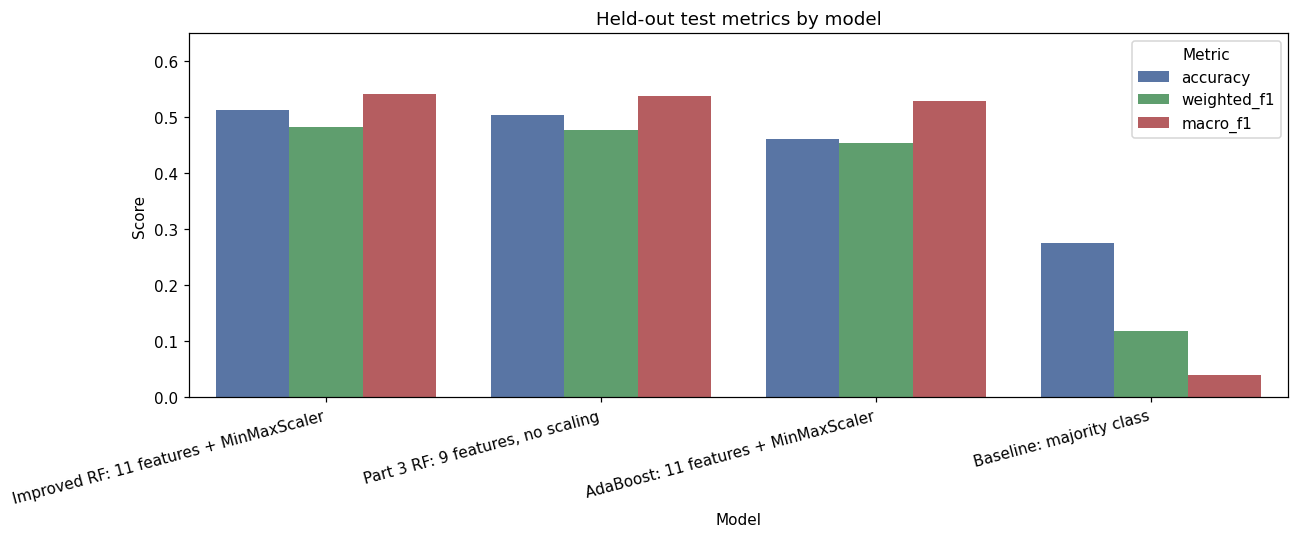

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

metrics_long = model_comparison.melt(
    id_vars='model',
    value_vars=['accuracy', 'weighted_f1', 'macro_f1'],
    var_name='metric',
    value_name='score',
)

plt.figure(figsize=(12, 5), dpi=110)
sns.barplot(
    data=metrics_long,
    x='model',
    y='score',
    hue='metric',
    palette={'accuracy': '#4C72B0', 'weighted_f1': '#55A868', 'macro_f1': '#C44E52'},
)
plt.ylim(0, 0.65)
plt.title('Held-out test metrics by model')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=15, ha='right')
plt.legend(title='Metric')
plt.tight_layout()
plt.show()


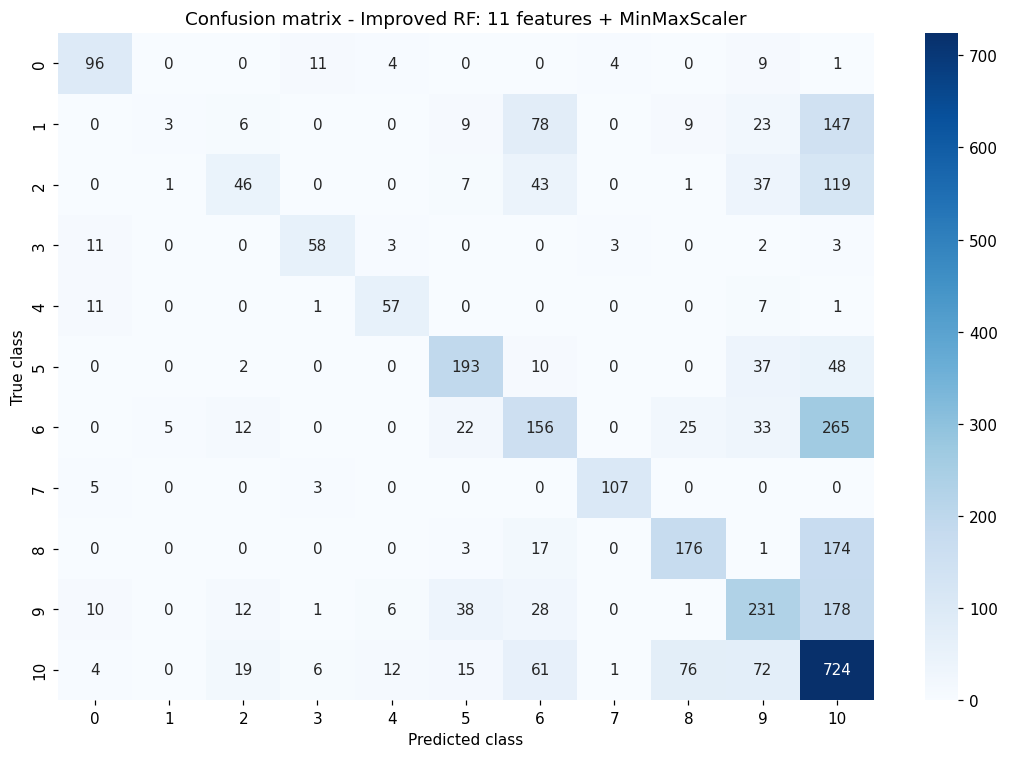

In [15]:
from sklearn.metrics import confusion_matrix

class_labels = sorted(y_test.unique())
cm = confusion_matrix(y_test, best_pred, labels=class_labels)

plt.figure(figsize=(10, 7), dpi=110)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels,
)
plt.title(f"Confusion matrix - {best_name}")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.tight_layout()
plt.show()


## <a id='section7'></a>7. Current Challenges

- **Performance ceiling.** Best accuracy on the held-out test fold is 51.3% (error rate ~48.7%). Whether planned work-class weights, gradient boosting, validation tuning-can raise that score is unknown until those models are fit and evaluated.
- **Class imbalance.** Class 1 F1 stays near zero; class 4 has only 77 test songs (387 in the full deduplicated CSV per Part 2). Macro F1 (54.2%) is higher than weighted F1 (48.3%) because several smaller classes perform relatively well, while some larger-support classes still have weaker F1. The per-class report remains necessary because the macro average can still hide the near-collapse of class 1.
- **Feature signal limits.** We model tabular audio summaries only; artist and track names are excluded to prevent memorization, and raw audio or lyrics are unavailable. Genres overlap in Spotify-style space.
- **Encoding gaps.** `key` is median-imputed and treated as numeric; Part 2 recommended categorical encoding but we have not validated it yet.
- **Metric tension.** Optimizing accuracy favors class 10; optimizing macro F1 would push toward rare genres. The final model choice needs an explicit priority.


## <a id='section8'></a>8. Plan for Completion

**Remaining tasks**

- Fit random forest with `class_weight='balanced'` inside the MinMaxScaler pipeline and re-evaluate class 1 recall.
- Try `HistGradientBoostingClassifier` or `GradientBoostingClassifier` with stratified cross-validation.
- One-hot encode `key` instead of median imputation; ablate whether mood columns (`valence`, `liveness`) help after encoding.
- Tune `max_depth`, `n_estimators`, and `min_samples_leaf` on the validation fold (reuse Part 3 sensitivity curves as starting points).
- Generate predictions for Kaggle `test.csv` with the finalized pipeline.
- Add feature-importance plot and misclassification sample table (Part 3 pattern).

**Planned final model.** Improved random forest with balanced class weights and tuned depth, unless gradient boosting beats it on macro F1 while keeping weighted F1 within one point of RF.

**Visuals still needed.** Feature importance from the final forest, per-class F1 comparison across top two models, optional ROC curves for the most confused class pairs.


## <a id='graduate'></a>Graduate Extension: Deeper Progress Analysis

### Tradeoff observed: macro F1 vs accuracy

The improved RF reports macro F1 (54.2%) above accuracy (51.3%). Rare classes with occasional high precision pull macro upward, while frequent misclassification into class 10 suppresses accuracy. AdaBoost inverted the gap differently: macro F1 (52.9%) exceeded accuracy (46.2%), indicating the booster chased hard examples without converting that focus into overall correctness. The comparison shows that ensemble choice interacts with which metric we optimize - bagging aligned better with weighted F1, boosting with macro F1 at the cost of accuracy.

### Limitation of the current approach

All features enter as numeric columns; `key` is median-imputed rather than categorically encoded. Artist identity is excluded by design. We rely on a single stratified holdout for every comparison instead of k-fold cross-validation, so point estimates for rare classes (e.g., class 4 with ~77 test songs) carry high variance. Part 2's energy–loudness–acousticness correlation cluster is unmanaged; trees split redundantly rather than through explicit regularization.

### Specific improvement before final submission

We will fit `RandomForestClassifier(class_weight='balanced')` inside the existing MinMaxScaler pipeline, evaluate on the same stratified test fold, and track class 1 recall explicitly. If recall remains below 0.10, we add stratified 5-fold CV before considering SMOTE. The decision criterion is macro F1 on classes 1, 4, and 6 - not headline accuracy alone.
